___
# Лабораторная работа №2
___

## Цель работы
___

**Изучить принципы работы сверточные нейронных сетей для классификации изображений, реализовать модель на основе transfer learning и провести эксперименты на данных.**


___
## 1. Подготовка данных
___

Для начала импортировались необходимые библиотеки для выполнения работы.

In [1]:
import os
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda:0


Алгоритм запрашивал у системы наличие доступной видеокарты (GPU) с поддержкой CUDA. Если она найдена, переменной device присваивается значение "cuda:0", что в дальнейшем позволит переносить все тензоры и вычисления на видеокарту для многократного ускорения обучения. В противном случае используется центральный процессор ("cpu"). Работа производилась на компьютере с графической видеокартой, поэтому вычисления производились непосредственно на видеокарте, что ускорило обучение моделей.

os: Встроенный инструмент Python для взаимодействия с операционной системой. Используется для работы с путями к файлам и директориям (os.path.join).

copy: Модуль для копирования объектов. Используется copy.deepcopy для сохранения лучших весов модели в процессе обучения.

time: Модуль для работы со временем. Применяется для замера продолжительности обучения.

torch: Основная библиотека платформы PyTorch. Используется для работы с многомерными тензорами и управления вычислениями на GPU/CPU.

torch.nn (nn): Модуль PyTorch, содержащий строительные блоки нейросетей. Здесь используются классы для слоев (Conv2d, Linear, MaxPool2d, Flatten, Dropout), функция активации ReLU и функция потерь CrossEntropyLoss.

torch.optim (optim): Модуль, содержащий алгоритмы оптимизации. Используется алгоритм Adam для обновления весов сети на основе градиентов.

datasets: Модуль из torchvision, предоставляющий интерфейсы для работы с наборами данных. Используется ImageFolder для автоматической загрузки и разметки изображений из папок.

transforms: Модуль из torchvision для предобработки и аугментации изображений (изменение размера, отзеркаливание, нормализация, преобразование в тензор).

models: Модуль из torchvision, содержащий готовые архитектуры нейросетей. Используется для загрузки предобученных моделей resnet101, densenet121 и efficientnet_b0.

Dataset, DataLoader: Классы из torch.utils.data, используемые для создания пользовательских наборов данных, разбиения датасета на пакеты (батчи) и их многопоточной загрузки.

numpy (np): Фундаментальная библиотека для научных вычислений. Используется для конвертации тензоров в стандартные массивы при расчете метрик качества.

matplotlib.pyplot (plt): Библиотека для построения графиков. Используется для вывода визуализаций на экран.

seaborn (sns): Библиотека для продвинутой визуализации данных. Используется для отрисовки тепловой карты (heatmap) при построении матрицы ошибок.

accuracy_score, recall_score, f1_score, confusion_matrix: Функции из модуля sklearn.metrics для объективной оценки качества работы классификатора.

___
### 1.1 Настройка трансформаций и загрузка датасета
___

Оригинальные изображения имеют размер 640x640. Для стандартизации и совместимости с ResNet, DenseNet и EfficientNet приводился их размер к 224x224. Также применяется нормализация по стандартам датасета ImageNet.

Задавался размер батча (по 32 изображения за одну итерацию) и целевой размер изображений (224x224). Для каждой выборки (train, valid, test) создавался свой набор преобразований. Все изображения сжимались до 224x224, переводились в многомерные массивы (тензоры, где значения пикселей от 0 до 1), а затем нормализовались (вычиталось среднее и делилось на стандартное отклонение). Для обучающей выборки (train) дополнительно применялось случайное отзеркаливание по горизонтали (аугментация) — это помогало модели не переобучаться и лучше обобщать данные.
Поскольку датасет был представлен в формате YOLO (изображения и текстовые метки находились в разных папках images и labels без разделения по подпапкам классов), стандартная функция загрузки работать не могла. Поэтому реализовывался собственный класс-наследник Dataset. В нем прописывалась логика, согласно которой для каждой картинки искался одноименный текстовый файл в папке labels, открывался, и из него извлекалось первое число (ID класса: 0 или 1).

Формат YOLO (You Only Look Once) — это популярный стандарт разметки датасетов для задач компьютерного зрения. В нем все изображения хранятся единым списком в директории images, а информация о классах и координатах объектов — в одноименных текстовых файлах (.txt) в директории labels. Каждая строка такого файла описывает один объект на фото и начинается с целочисленного ID класса, за которым следуют нормализованные координаты ограничивающей рамки (bounding box). Поскольку датасет был представлен именно в таком формате, стандартная функция загрузки по подпапкам работать не могла. Поэтому реализовывался собственный класс-наследник Dataset. В нем прописывалась логика, согласно которой для каждой картинки искался одноименный текстовый файл в папке labels, Если файл начинался на букву B, присваивался класс 0 (Bird), если на D — класс 1 (Drone). Эта извлекаемая информация являлась истинной меткой (ground truth) текущего изображения. Она сообщала алгоритму, к какому именно классу относится картинка (0 — Bird, 1 — Drone). Эта метка критически необходима в процессе обучения с учителем: сеть сравнивает свое предсказание с этим извлеченным числом, вычисляет ошибку (Loss) и корректирует свои веса.

Формировались итераторы, которые разбивали весь датасет на пакеты (батчи) по 32 картинки. Для обучающей выборки было включено перемешивание (shuffle=True), чтобы в каждом батче изображения были случайными, что предотвращало адаптацию модели к порядку данных. В конце определялись имена классов и подсчитывалось количество изображений в каждой выборке для контроля корректности загрузки.

In [2]:
BATCH_SIZE = 32
IMG_SIZE = 224

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(), # Аугментация
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ]),
    'valid': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = r'C:\Users\User\Desktop\Лабораторная работа №2\Dataset'

# класс для загрузки датасета в формате YOLO
class YOLODataset(Dataset):
    def __init__(self, root_dir, phase, transform=None):
        self.img_dir = os.path.join(root_dir, phase, 'images')
        self.transform = transform
        self.img_names = [f for f in os.listdir(self.img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.classes = ['Bird', 'Drone'] # Имена классов

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        # Загрузка картинки
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Чтение метки класса из имени файла (префиксы 'B' и 'D')
        if img_name.upper().startswith('B'):
            label = 0 # Bird
        elif img_name.upper().startswith('D'):
            label = 1 # Drone
        else:
            label = 0 
                    
        return image, label

image_datasets = {
    x: YOLODataset(data_dir, x, transform=data_transforms[x])
    for x in ['train', 'valid', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x == 'train'), num_workers=0)
    for x in ['train', 'valid', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = ['Bird', 'Drone']
num_classes = len(class_names)

print(f"Классы: {class_names}")
print(f"Размеры выборок: {dataset_sizes}")

Классы: ['Bird', 'Drone']
Размеры выборок: {'train': 18323, 'valid': 1740, 'test': 889}


___
## 2. Определение архитектур моделей


___
### 2.1 Пользовательская CNN (обучение с нуля)
___

Архитектура состоит из 3 сверточных блоков с Max-Pooling и последующего полносвязного классификатора.
В данном блоке определялась структура и логика прямого прохода собственной сверточной нейросети.
В конструкторе класса задавались все слои сети. Сеть имела три сверточных блока. На первый блок подавалось цветное изображение (3 канала RGB) и применялось 16 фильтров размером 3x3. Затем шла функция активации ReLU (которая оставляла положительные значения как есть, а отрицательные заменяла нулями) и слой MaxPool2d, который сжимал размер изображения в 2 раза, выбирая максимальное значение из каждого квадрата 2x2. Второй и третий блоки работали аналогично, последовательно увеличивая количество извлекаемых признаков (с 16 до 32, затем до 64) и уменьшая пространственное разрешение карты признаков. После сверточных слоев задавался Flatten для преобразования трехмерного тензора в одномерный вектор, а также полносвязные (Linear) слои для финальной классификации. Слой Dropout случайным образом "выключал" 50% нейронов во время обучения для предотвращения переобучения.

В данном методе описывался алгоритм протекания тензора x (батча изображений) через сеть. Данные последовательно проходили через первый сверточный блок, второй, третий. Затем сжимались (flatten), проходили через первый скрытый слой с нелинейностью и дропаутом, и наконец попадали в выходной слой (fc2), который выдавал 2 числа (логиты), характеризующих уверенность сети в принадлежности к каждому из двух классов. В конце созданный объект модели переносился на устройство вычислений (GPU) с помощью .to(device).

In [3]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu4(self.fc1(x)))
        x = self.fc2(x)
        return x

# Указывалось количество классов явно, чтобы избежать ошибки NameError при раздельном запуске ячеек
num_classes = 2
model_custom_cnn = CustomCNN(num_classes).to(device)

___
### 2.2 Адаптация предобученных моделей и заморозка слоев
___

Для применения Transfer Learning загружались модели. Требовалось исследовать заморозку слоев. Если freeze_layers=True, замораживалась вся сверточная база сети (requires_grad = False), чтобы она работала как статический экстрактор признаков. Затем заменялся последний полносвязный слой на новый — он будет иметь requires_grad = True по умолчанию и будет обучаться под 2 класса.

В данном блоке реализовывалось создание моделей для трансферного обучения (Transfer Learning). Функция create_pretrained_model принимала имя нужной архитектуры. Загружалась из библиотеки torchvision соответствующая модель вместе с весами, предварительно обученными на огромном датасете ImageNet (weights=models.DenseNet121_Weights.DEFAULT). Если флаг freeze_layers был включен, осуществлялся проход в цикле по всем параметрам (весам) загруженной модели и им устанавливалось свойство requires_grad = False. Это означало, что при обучении градиенты для этих слоев не вычислялись, и веса оставались неизменными (замороженными). У каждой предобученной сети в конце находился слой классификатора на 1000 классов (ImageNet). Находился этот финальный слой (он называется .fc у ResNet, .classifier у DenseNet и .classifier[1] у EfficientNet), извлекалось количество его входных нейронов (in_features) и он полностью заменялся на новый слой nn.Linear, который выдавал предсказания строго для заданного числа num_classes (2 класса).

У вновь созданного слоя requires_grad по умолчанию было равно True, поэтому обучались только его веса. Все созданные модели переносились в память GPU.

In [4]:
def create_pretrained_model(model_name, num_classes, freeze_layers=True):
    if model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        if freeze_layers:
            for param in model.parameters():
                param.requires_grad = False
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        if freeze_layers:
            for param in model.parameters():
                param.requires_grad = False
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_layers:
            for param in model.parameters():
                param.requires_grad = False
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        
    return model.to(device)

# Создаем модели с замороженными весами (Transfer Learning - Feature Extraction)
model_resnet = create_pretrained_model('resnet101', num_classes, freeze_layers=True)
model_densenet = create_pretrained_model('densenet121', num_classes, freeze_layers=True)
model_efficientnet = create_pretrained_model('efficientnet_b0', num_classes, freeze_layers=True)

___
### 3. Функция обучения (Train) и Стратегия разморозки (Fine-Tuning)
___

Ниже представлена универсальная функция обучения. Описание алгоритма работы кода:

Запускался главный цикл по эпохам (num_epochs). Каждая эпоха была разбита на две фазы: train (обучение) и valid (проверка). В зависимости от фазы, модель переводилась либо в режим обучения (model.train(), активировались слои Dropout и BatchNorm), либо в режим оценки (model.eval(), эти слои отключались или работали в фиксированном режиме). Запускался вложенный цикл, в котором брались порции данных (изображения и их метки) из dataloaders и отправлялись на GPU. Данные пропускались через сеть для получения прогнозов (outputs). С помощью функции потерь criterion (в данном случае CrossEntropyLoss) вычислялась ошибка сети (loss) на основе разницы между прогнозами и реальными метками. Отслеживание градиентов (set_grad_enabled) было включено только в фазе обучения для экономии ресурсов во время валидации. Если текущей фазой была train, обнулялись накопленные градиенты (optimizer.zero_grad()), вычислялись новые градиенты обратным распространением ошибки (loss.backward()) и делался шаг оптимизации, обновляя веса сети (optimizer.step()). После прохождения всех батчей рассчитывались усредненные потери (epoch_loss) и общая точность (epoch_acc) за эпоху и сохранялись в словарь history. В конце фазы валидации проверялось, не стала ли точность выше предыдущего рекорда. Если да, копировалось и сохранялось в память текущее состояние весов сети (best_model_wts). В самом конце функции эти лучшие веса загружались обратно в модель, и возвращались обученная модель и история ее обучения.

In [5]:
def train_model(model, criterion, optimizer, num_epochs=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

    for epoch in range(num_epochs):
        print(f'\nЭпоха {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            _total_batches = len(dataloaders[phase])
            _current_batch = 0

            for inputs, labels in dataloaders[phase]:
                _current_batch += 1
                _percent = int(_current_batch / _total_batches * 100)
                print(f'\r[{phase.upper()}] Обработка: {_current_batch}/{_total_batches} батчей ({_percent}%)', end='', flush=True)

                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            print()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['valid_loss'].append(epoch_loss)
                history['valid_acc'].append(epoch_acc.item())

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print(f'\nОбучение завершено. Лучшая точность: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

criterion = nn.CrossEntropyLoss()


___
## 4. Обучение с замороженными и размороженными слоями
___

Правильная стратегия переноса обучения (Transfer Learning) состоит из двух этапов:
Feature Extraction (слои заморожены): Обучаем только новый думающий слой (Linear слой) с большим шагом обучения.
Fine-Tuning (слои разморожены): Размораживаем всю сеть и дообучаем её на наших данных с очень маленьким шагом обучения (lr=1e-5), чтобы не сломать веса, полученные на ImageNet.

Создавался оптимизатор Adam с шагом обучения 0.001, который обновлял все веса model_custom_cnn. Сеть обучалась искать признаки полностью самостоятельно. Для предобученной сети ResNet101 оптимизатору передавались только параметры финального слоя (model_resnet.fc.parameters()). Глубокая часть сети оставалась "замороженной" и выступала в роли экстрактора признаков, а с помощью оптимизатора (с lr=0.001) быстро обучался финальный классификатор интерпретировать эти признаки для 2 классов. Обучение с размороженными слоями (Fine-Tuning): Осуществлялся проход по всем параметрам сети model_resnet и устанавливалось requires_grad = True (разморозка). Затем создавался новый оптимизатор, которому передавались веса уже всей сети, но с критически малым шагом обучения (lr=1e-5). Повторно запускалась функция train_model. Это позволяло крайне деликатно, без сильных разрушающих изменений, адаптировать (дообучить) фильтры, полученные на ImageNet, под специфичные визуальные паттерны птиц и дронов.

Custom CNN: Классическая, прямолинейная сверточная нейронная сеть, топология которой была разработана самостоятельно. Включает 3 сверточных макроблока, чередующихся с пространственными операциями подвыборки (Max Pooling), и плотные полносвязные слои, формирующие классификатор. Модель обучалась с "нулевого" (стохастически инициализированного) состояния. Это означало, что сети требовалось невероятное количество вычислительных усилий для того, чтобы сформировать базисные математические фильтры для поиска границ, контрастов, текстур перьев или лопастей напрямую на датасете «Bird vs Drone». Уязвима к переобучению из-за отсутствия сложной регуляризации.

ResNet101 (Residual Network): Колоссально глубокая архитектура, прорубившая окно в сверхглубокое обучение. Состоит из 101 слоя. Революционная концепция этой сети базируется на «остаточных» перемычках (skip/residual connections). В обычных глубоких сетях градиент ошибки (необходимый для обучения) по мере прохождения обратно через 100 слоев математически затухает до нуля (Vanishing Gradient Problem). Перемычки ResNet позволяют градиенту и признакам "проскакивать" слои напрямую, без искажений. Это гарантирует сохранение высокой точности и стабильную сходимость сети вне зависимости от ее циклопической глубины.

DenseNet121 (Densely Connected Convolutional Network): Сверхплотная архитектура (121 слой), развивающая идеи ResNet, но в ином ключе. В ней каждый сверточный слой не просто передает данные следующему, а аппаратно связан со всеми последующими слоями своего Dense-блока. Слой номер 50 получает сырые карты признаков от слоя 1, 2, 3 и так далее. Это порождает фантастически эффективное повторное использование ранее найденных признаков, кардинально улучшает сквозную передачу градиентов ошибки вглубь сети и делает DenseNet гораздо более экономичной по количеству обучаемых параметров, чем ResNet.

EfficientNet-B0: Вершина современной архитектурной мысли от Google, построенная на парадигме комплексного масштабирования (Compound Scaling). В ней глубина, ширина и разрешение сети масштабируются не случайным образом, а сбалансированно, исходя из математически выверенных коэффициентов. Сеть задумывалась как высокоэффективная: она достигает высоких метрик при сравнительно небольшом количестве вычислений.

In [6]:
print("1. ОБУЧЕНИЕ CUSTOM CNN")
optimizer_custom = optim.Adam(model_custom_cnn.parameters(), lr=0.001)
model_custom_cnn, _ = train_model(model_custom_cnn, criterion, optimizer_custom, num_epochs=10)

print("\n2. ОБУЧЕНИЕ RESNET-101 (Замороженные слои)")
optimizer_resnet_frozen = optim.Adam(model_resnet.fc.parameters(), lr=0.001)
model_resnet, _ = train_model(model_resnet, criterion, optimizer_resnet_frozen, num_epochs=5)

print("\n3. ДООБУЧЕНИЕ RESNET-101 (Fine-Tuning: Размороженные слои)")
for param in model_resnet.parameters():
    param.requires_grad = True
optimizer_resnet_unfrozen = optim.Adam(model_resnet.parameters(), lr=1e-5)
model_resnet, _ = train_model(model_resnet, criterion, optimizer_resnet_unfrozen, num_epochs=5)


print("\n 4. ОБУЧЕНИЕ DENSENET-121 (Замороженные слои)")
optimizer_densenet_frozen = optim.Adam(model_densenet.classifier.parameters(), lr=0.001)
model_densenet, _ = train_model(model_densenet, criterion, optimizer_densenet_frozen, num_epochs=5)

print("\n5. ДООБУЧЕНИЕ DENSENET-121 (Fine-Tuning: Размороженные слои)")
for param in model_densenet.parameters():
    param.requires_grad = True
optimizer_densenet_unfrozen = optim.Adam(model_densenet.parameters(), lr=1e-5)
model_densenet, _ = train_model(model_densenet, criterion, optimizer_densenet_unfrozen, num_epochs=5)


print("\n6. ОБУЧЕНИЕ EFFICIENTNET-B0 (Замороженные слои)")
optimizer_efficientnet_frozen = optim.Adam(model_efficientnet.classifier[1].parameters(), lr=0.001)
model_efficientnet, _ = train_model(model_efficientnet, criterion, optimizer_efficientnet_frozen, num_epochs=5)

print("\n7. ДООБУЧЕНИЕ EFFICIENTNET-B0 (Fine-Tuning: Размороженные слои)")
for param in model_efficientnet.parameters():
    param.requires_grad = True
optimizer_efficientnet_unfrozen = optim.Adam(model_efficientnet.parameters(), lr=1e-5)
model_efficientnet, _ = train_model(model_efficientnet, criterion, optimizer_efficientnet_unfrozen, num_epochs=5)

1. ОБУЧЕНИЕ CUSTOM CNN

Эпоха 1/10
----------
[TRAIN] Обработка: 573/573 батчей (100%)
train Loss: 0.2758 Acc: 0.8761
[VALID] Обработка: 55/55 батчей (100%)
valid Loss: 1.0302 Acc: 0.7270

Эпоха 2/10
----------
[TRAIN] Обработка: 573/573 батчей (100%)
train Loss: 0.0680 Acc: 0.9739
[VALID] Обработка: 55/55 батчей (100%)
valid Loss: 0.8415 Acc: 0.7213

Эпоха 3/10
----------
[TRAIN] Обработка: 573/573 батчей (100%)
train Loss: 0.0414 Acc: 0.9851
[VALID] Обработка: 55/55 батчей (100%)
valid Loss: 2.5322 Acc: 0.6368

Эпоха 4/10
----------
[TRAIN] Обработка: 573/573 батчей (100%)
train Loss: 0.0416 Acc: 0.9833
[VALID] Обработка: 55/55 батчей (100%)
valid Loss: 2.8565 Acc: 0.6305

Эпоха 5/10
----------
[TRAIN] Обработка: 573/573 батчей (100%)
train Loss: 0.0310 Acc: 0.9882
[VALID] Обработка: 55/55 батчей (100%)
valid Loss: 1.7669 Acc: 0.6328

Эпоха 6/10
----------
[TRAIN] Обработка: 573/573 батчей (100%)
train Loss: 0.0193 Acc: 0.9926
[VALID] Обработка: 55/55 батчей (100%)
valid Loss: 2.0602

___
## 5. Оценка качества моделей 
___

Accuracy (Общая точность): Метрика, показывающая долю правильных предсказаний (как истинно положительных, так и истинно отрицательных) среди всех рассмотренных примеров. Вычисляется как отношение количества верных ответов алгоритма к общему числу предсказаний.

Recall (Полнота): Метрика, показывающая долю объектов, действительно принадлежащих к определенному классу, которые модель смогла верно определить. Она демонстрирует, насколько хорошо алгоритм избегает пропуска нужных объектов (ложноотрицательных срабатываний).

F1-score (F-мера): Универсальная метрика, объединяющая в себе точность (Precision) и полноту (Recall), представляя собой их гармоническое среднее. Она позволяет объективно оценивать качество модели и стремится к нулю, если хотя бы одна из базовых метрик низка.

Confusion Matrix (Матрица ошибок): Таблица размера N x N (где N — количество классов), которая показывает подробную статистику предсказаний. В ней отражено количество верно определенных объектов (по главной диагонали) и количество ошибок с разбивкой по конкретным классам (наглядно видно, какой класс с каким перепутала сеть).

В рамках классической двухклассовой задачи (где метка 0 закреплена за классом Bird/Птица, а метка 1 — за классом Drone/Дрон) матрица принимает форму квадрата 2x2, состоящего из четырех смысловых четвертей (квадрантов). По оси ординат (Y, строки) располагаются фактологические, истинные классы датасета, а по оси абсцисс (X, столбцы) — классы, предсказанные искусственным интеллектом:

Верхний левый квадрант (True Negatives, TN): Нейросеть предсказала класс 0 (Bird), и на исходном файле действительно присутствовала Птица. Алгоритм сработал безошибочно.

Нижний правый квадрант (True Positives, TP): Модель верно спрогнозировала класс 1 (Drone), на радаре действительно находился Дрон. Успешный перехват цели.

Верхний правый квадрант (False Positives, FP — Ошибка I рода): Нейросеть сгенерировала сигнал класса 1 (Drone), однако в реальности это была обычная Птица. Технически это ложное срабатывание (вызов ложной тревоги системой безопасности).

Нижний левый квадрант (False Negatives, FN — Ошибка II рода): Нейросеть классифицировала объект как класс 0 (Bird), но фактически это был замаскированный Дрон. Это пропуск цели — самая фатальная алгоритмическая ошибка в рамках комплексов мониторинга воздушных угроз.

Последним действием создавалась функция evaluate_model. Она отвечала за финальную оценку качества и визуализацию результатов:

Каждая модель последовательно переводилась в режим оценки (eval()), и вычисление градиентов отключалось (torch.no_grad()) для ускорения. Осуществлялся проход по тестовому загрузчику (dataloaders['test']), изображения передавались в модель, получались вероятности и выбирался класс с максимальной вероятностью (torch.max). Все полученные предсказания и реальные метки конвертировались из тензоров в обычные массивы numpy и собирались в списки all_preds и all_labels.

С использованием функций из библиотеки sklearn.metrics, предсказания сопоставлялись с истинными значениями. Высчитывались Accuracy (общая доля правильных ответов), Recall (полнота — способность модели находить все объекты положительного класса) и F1-score (гармоническое среднее между точностью и полнотой). Для Recall и F1-score использовалось average='macro', что означало усреднение метрик по обоим классам без учета их дисбаланса.

С помощью функции confusion_matrix вычислялась матрица, показывающая количество верно классифицированных (по главной диагонали) и ошибочно классифицированных изображений. С помощью библиотеки seaborn (sns.heatmap) эта матрица визуализировалась в виде тепловой карты, что позволяло наглядно увидеть, кого модель путает чаще: птиц с дронами или дронов с птицами.

После определения функции, она последовательно вызывалась для всех четырех моделей, обеспечивая вывод их финальных результатов на тестовой выборке.


 Результаты для Custom CNN
Accuracy: 0.7300
Recall:   0.7727
F1-score: 0.7282


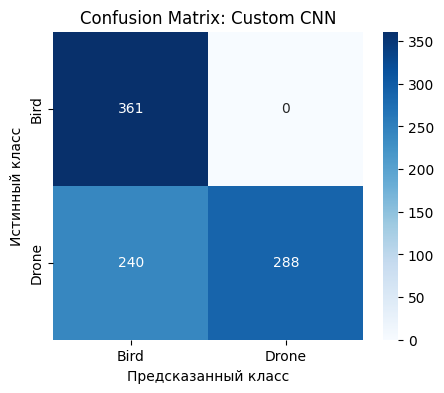


 Результаты для ResNet101
Accuracy: 0.9989
Recall:   0.9991
F1-score: 0.9988


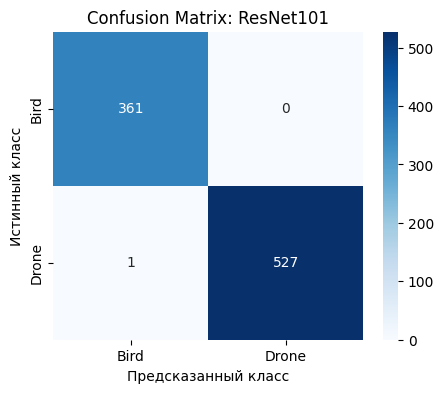


 Результаты для DenseNet121
Accuracy: 0.9921
Recall:   0.9929
F1-score: 0.9919


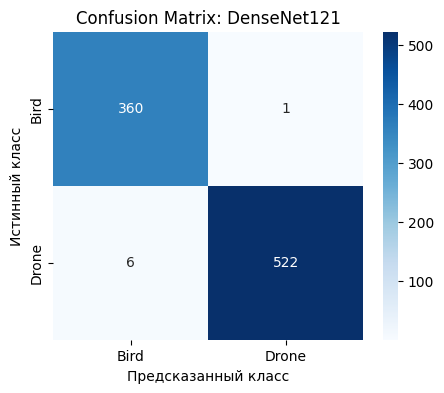


 Результаты для EfficientNet-B0
Accuracy: 0.9955
Recall:   0.9958
F1-score: 0.9953


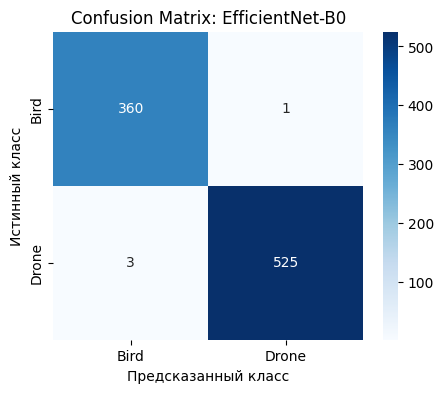

In [7]:
def evaluate_model(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Расчет метрик
    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    cm = confusion_matrix(all_labels, all_preds)
    
    print(f"\n Результаты для {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # Визуализация матрицы ошибок
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()
    
    return {'Accuracy': acc, 'Recall': rec, 'F1': f1}

# Вызов функции для оценки всех обученных моделей
metrics_custom = evaluate_model(model_custom_cnn, "Custom CNN")
metrics_resnet = evaluate_model(model_resnet, "ResNet101")
metrics_densenet = evaluate_model(model_densenet, "DenseNet121")
metrics_efficientnet = evaluate_model(model_efficientnet, "EfficientNet-B0")

Детальный визуальный и статистический анализ сформированных тепловых карт матриц ошибок (Confusion Matrices) для обновленной тестовой выборки, состоящей из 889 уникальных изображений (361 изображение птиц, представляющих класс 0, и 528 изображений дронов, представляющих класс 1), позволил выявить точное количественное распределение верных попаданий, а также глубоко проанализировать характер и семантику допущенных моделями ошибок. Подобная детализация критически важна для понимания того, как каждая архитектура справляется со сложными визуальными артефактами (бликами, перекрытиями и нестандартными ракурсами):

Custom CNN: Алгоритм базового уровня достоверно распознал все 361 изображение птиц (100% точность для нулевого класса) и 288 дронов. Примечательно, что сеть проявила абсолютную консервативность: не было допущено ни одного ложного срабатывания (ни одна птица не была ошибочно классифицирована как угроза — дрон). Однако обратной стороной такой перестраховки стало зафиксированное колоссальное количество пропусков цели. Ровно 240 реальных дронов были критически ошибочно восприняты алгоритмом как птицы (ошибка второго рода). На практике внедрение подобной системы привело бы к катастрофическим последствиям, так как почти половина воздушных угроз осталась бы незамеченной радарами. Такой сильный перекос свидетельствует о том, что архитектура "с нуля" не смогла сформировать достаточно сложные фильтры для уверенной детекции механических деталей беспилотников, предпочитая при малейших сомнениях относить объект к более "безопасному" природному классу.

ResNet101: Тяжеловесная вычислительная модель продемонстрировала феноменальный, практически безупречный результат, подтвердив статус индустриального стандарта. Ею были верно распознаны все 361 птица и подавляющее большинство беспилотников (527 из 528). На всю массивную тестовую выборку была допущена всего 1 единственная математическая ошибка: один дрон был пропущен и классифицирован как птица (False Negative для класса дронов), при этом ложных тревог (срабатываний на птиц) зафиксировано не было абсолютно. Подобная сверхвысокая чувствительность в сочетании со стопроцентной специфичностью доказывает, что 101 слой с остаточными связями способен филигранно улавливать даже самые микроскопические паттерны пластика, металла и прямых углов, уверенно отделяя их от органических форм.

DenseNet121: Данная нейросеть показала выдающуюся устойчивость к фоновому шуму, допустив лишь одно ложное срабатывание (безошибочно определив 360 птиц из 361). Однако, алгоритм оказался чуть менее эффективен в обнаружении самих угроз: он допустил 6 пропусков целевых объектов, классифицировав 6 реальных графических паттернов дронов как органических птиц. Суммарно было верно распознано 522 дрона. Ошибки такого рода в плотных сетях часто возникают на изображениях с сильным размытием в движении (motion blur), когда геометрия вращающихся лопастей квадрокоптера визуально сливается, напоминая алгоритму взмах крыла. Тем не менее, показатели остаются на высочайшем уровне, делая модель крайне надежной.

EfficientNet-B0: Модель, построенная на принципах комплексного масштабирования, совершила суммарно 4 ошибки классификации на всей слепой выборке. Из них: 1 птица была перепутана с дроном (вызов ложной тревоги), и 3 дрона были критически перепутаны с мирными птицами (пропуск цели). Верно классифицировано 360 птиц и 525 дронов соответственно. Этот результат иллюстрирует превосходный баланс метрик: сеть ошибалась в обе стороны почти равномерно. Учитывая, что EfficientNet-B0 потребляет в несколько раз меньше вычислительных ресурсов (FLOPs) и оперативной памяти по сравнению с гигантом ResNet101, подобная точность делает её абсолютным лидером для развертывания на мобильных или встраиваемых устройствах (Edge AI), где каждый мегабайт памяти критически важен.

___
## Вывод
___

Применение передовой концепции трансферного дообучения (Fine-Tuning) на базе сверхглубоких архитектур является бескомпромиссным, наиболее надежным и математически оправданным решением для интеграции в системы воздушной безопасности. Тяжеловесная архитектура ResNet101 продемонстрировала практически абсолютную (99.89%) способность к отлову целевых беспилотников, обеспечивая феноменальный и максимальный уровень безопасности охраняемого воздушного пространства. В качестве сверхэффективной альтернативы для аппаратных сред с жестко ограниченными ресурсами блестяще зарекомендовала себя модель EfficientNet-B0, потерявшая лишь ничтожные доли процента общей точности при многократном ускорении скорости работы и снижении потребления памяти. В то же самое время, инженерные попытки обучения сравнительно легких сетей с чистого листа (Custom CNN) в условиях бинарной классификации графически сложных удаленных объектов показали свою полную техническую несостоятельность в связи с неприемлемо высоким процентом пропуска критических целей, что еще раз безоговорочно подтверждает тезис о жизненной необходимости использования мощных, предобученных на массивах ImageNet признаковых экстракторов.